# Formula 1 World Championship Analysis
## Machine Learning
* **Goal:** Predict the probability of a Formula 1 driver winning a race based on historical driver performance, constructor performance and qualifying position.

In [73]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    confusion_matrix, 
    classification_report
)
from sklearn.dummy import DummyClassifier

In [26]:
# Safe data loading with try/except
file_path = ('../data/formula_dataset_ml.csv')

try:
    df = pd.read_csv(file_path)
    print('File loaded successfully')
except FileNotFoundError:
    print(f'File not Found - Check {file_path}')
except Exception as e:
    print(f'Error occurred - Check {e}')

File loaded successfully


In [27]:
# Inspection of Dataset

print(df.shape)
print(df.head())
print(df.columns)

(26759, 15)
   grid  pole_position  year  previous_races  previous_wins  \
0     1              1  1950               0              0   
1     2              0  1950               0              0   
2     4              0  1950               0              0   
3     6              0  1950               0              0   
4     9              0  1950               0              0   

   previous_win_rate  previous_points  previous_avg_position  \
0                0.0              0.0                    NaN   
1                0.0              0.0                    NaN   
2                0.0              0.0                    NaN   
3                0.0              0.0                    NaN   
4                0.0              0.0                    NaN   

   previous_podiums  previous_podium_rate  previous_constructor_wins  \
0                 0                   0.0                          0   
1                 0                   0.0                          0   
2       

In [28]:
# Define features and target
X = df.drop('win', axis=1)
y = df['win']

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (26759, 14)
Target shape: (26759,)


In [29]:
# Check target distribution
print(y.value_counts())
print()
print(y.value_counts(normalize=True))

win
0    25631
1     1128
Name: count, dtype: int64

win
0    0.957846
1    0.042154
Name: proportion, dtype: float64


In [30]:
# Checking for the missing values
print(X.isna().sum())

grid                               0
pole_position                      0
year                               0
previous_races                     0
previous_wins                      0
previous_win_rate                  0
previous_points                    0
previous_avg_position            861
previous_podiums                   0
previous_podium_rate               0
previous_constructor_wins          0
previous_constructor_points        0
previous_constructor_races         0
previous_constructor_win_rate      0
dtype: int64


In [31]:
# Check available seasons
print(df['year'].min())
print(df['year'].max())

1950
2024


In [32]:
# Define ML features
ml_features = [
    'grid',
    'pole_position',
    'previous_races',
    'previous_wins',
    'previous_win_rate',
    'previous_points',
    'previous_avg_position',
    'previous_podiums',
    'previous_podium_rate',
    'previous_constructor_wins',
    'previous_constructor_points',
    'previous_constructor_races',
    'previous_constructor_win_rate'
]

target = 'win'

print('Number of features:', len(ml_features))
print('Target:', target)

Number of features: 13
Target: win


In [33]:
# Split data chronologically
train_df = df[df['year']<= 2019].copy()
test_df = df[df['year'] >= 2020].copy()

print('Training set:', train_df.shape)
print('Test set:', test_df.shape)

Training set: (24620, 15)
Test set: (2139, 15)


In [34]:
# Check of the right splitting

# Trainset
print(
    'Training years:',
    train_df['year'].min(), 
    '-',
    train_df['year'].max()
)

# Testset
print(
    'Test years:', 
    test_df['year'].min(), 
    '-',
    test_df['year'].max()
)

Training years: 1950 - 2019
Test years: 2020 - 2024


In [35]:
# Define training and test features and target

X_train = train_df[ml_features]
y_train = train_df[target]

X_test = test_df[ml_features]
y_test = test_df[target]

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

X_train: (24620, 13)
y_train: (24620,)
X_test: (2139, 13)
y_test: (2139,)


In [43]:
# Create imputer

imputer = SimpleImputer(strategy='median')

# Fit on training data and transform training data
X_train_imputer = imputer.fit_transform(X_train)
X_test_imputer = imputer.transform(X_test)

In [41]:
# Check the sum of missing values
print('Missing values in X_train:', np.isnan(X_train_imputer).sum())
print('Missing valeus in X_test:', np.isnan(X_test_imputer).sum())

Missing values in X_train: 0
Missing valeus in X_test: 0


In [ ]:
# Create baseline model

baseline = DummyClassifier(strategy='most_frequent')

baseline.fit(X_train_imputer, y_train)
baseline_prediction = baseline.predict(X_test_imputer)

In [46]:
# Check Accuracy Score

baseline_accuracy = accuracy_score(y_test, baseline_prediction)
print(f'Baseline Accuracy Score: {baseline_accuracy*100:.2f}%')


Baseline Accuracy Score: 95.00%


In [ ]:
# Confusion Matrix

print(confusion_matrix(y_test, baseline_prediction))

[[2032    0]
 [ 107    0]]


In [48]:
# Classification Report
print(classification_report(y_test, baseline_prediction))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      2032
           1       0.00      0.00      0.00       107

    accuracy                           0.95      2139
   macro avg       0.47      0.50      0.49      2139
weighted avg       0.90      0.95      0.93      2139



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [49]:
# Import Logisitc Regression for next ML Model
from sklearn.linear_model import LogisticRegression

In [50]:
# Create LR model
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

In [51]:
# Train the model
lr_model.fit(
    X_train_imputer,
    y_train
)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [52]:
# Make prediction
lr_model_prediction = lr_model.predict(X_test_imputer)

In [53]:
# Check Classification Report
print(
    classification_report(
        y_test, 
        lr_model_prediction
    )
)

              precision    recall  f1-score   support

           0       0.99      0.83      0.90      2032
           1       0.21      0.89      0.34       107

    accuracy                           0.83      2139
   macro avg       0.60      0.86      0.62      2139
weighted avg       0.95      0.83      0.87      2139



In [54]:
# Confusion Matrix - LR Model
print(
    confusion_matrix(
        y_test, 
        lr_model_prediction
    )
)

[[1677  355]
 [  12   95]]


In [55]:
# Import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

In [56]:
# Create RF Model
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42, 
    n_jobs=1
)

In [57]:
# Train Random Forest
rf_model.fit(
    X_train_imputer, 
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
# Make prediction with RF Model
rf_model_prediction = rf_model.predict(
    X_test_imputer
)

In [59]:
# Evaluate the Model
print(
    classification_report(
        y_test,
        rf_model_prediction
    )
)

              precision    recall  f1-score   support

           0       0.95      1.00      0.98      2032
           1       0.69      0.10      0.18       107

    accuracy                           0.95      2139
   macro avg       0.82      0.55      0.58      2139
weighted avg       0.94      0.95      0.94      2139



In [60]:
# Confusion Matrix - RF Model
print(
    confusion_matrix(
        y_test, 
        rf_model_prediction
    )
)

[[2027    5]
 [  96   11]]


In [61]:
# Get feature importance from RF Model
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='importance', 
    ascending=False
)
print(
    feature_importance
)


                          feature  importance
0                            grid    0.237659
8            previous_podium_rate    0.135047
4               previous_win_rate    0.103513
7                previous_podiums    0.076506
12  previous_constructor_win_rate    0.068728
5                 previous_points    0.059984
3                   previous_wins    0.059689
6           previous_avg_position    0.059057
2                  previous_races    0.041937
11     previous_constructor_races    0.040942
10    previous_constructor_points    0.040717
9       previous_constructor_wins    0.039044
1                   pole_position    0.037176


In [62]:
# Start with Hyperparameter adjustment
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

In [63]:
# Create Parameter for GridSearch
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [64]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5, 
    n_jobs=1
)

In [65]:
# Train GridSearch
rf_grid.fit(
    X_train_imputer, 
    y_train
)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,scoring,'f1'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [66]:
# Check for best parameters
print('Best parameters:')
print(rf_grid.best_params_)

Best parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
# Check for best F1 Score
print('Best CV F1 Score:')
print(rf_grid.best_score_)

Best CV F1 Score:
0.20687452036876727


In [68]:
best_rf = rf_grid.best_estimator_

In [69]:
rf_best_prediction = best_rf.predict(X_test_imputer)

In [70]:
# Evaluate the GridSearch Model
print(
    classification_report(
        y_test, 
        rf_best_prediction
    )
)

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      2032
           1       0.57      0.45      0.50       107

    accuracy                           0.96      2139
   macro avg       0.77      0.72      0.74      2139
weighted avg       0.95      0.96      0.95      2139



In [71]:
# Confusion Matrix with GridSearch Model
print(
    confusion_matrix(
        y_test, 
        rf_best_prediction
    )
)

[[1996   36]
 [  59   48]]


## Hyperparameter Tuning

GridSearchCV was used to optimize the Random Forest classifier.
The F1-score was selected as the scoring metric because the target
variable is highly imbalanced.

The tuned model achieved an F1-score of 0.50 for the minority class
(win = 1), compared with 0.18 for the initial Random Forest model.

In [72]:
# Feature Importance for GridSearched RF Model

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
})

# Sort Values
feature_importance = feature_importance.sort_values(
    by='importance', 
    ascending=False
)
print(feature_importance)

                          feature  importance
4               previous_win_rate    0.105238
0                            grid    0.098263
8            previous_podium_rate    0.094532
6           previous_avg_position    0.090038
12  previous_constructor_win_rate    0.078734
11     previous_constructor_races    0.074636
1                   pole_position    0.074264
10    previous_constructor_points    0.072855
5                 previous_points    0.072678
2                  previous_races    0.069889
7                previous_podiums    0.058205
9       previous_constructor_wins    0.055761
3                   previous_wins    0.054907


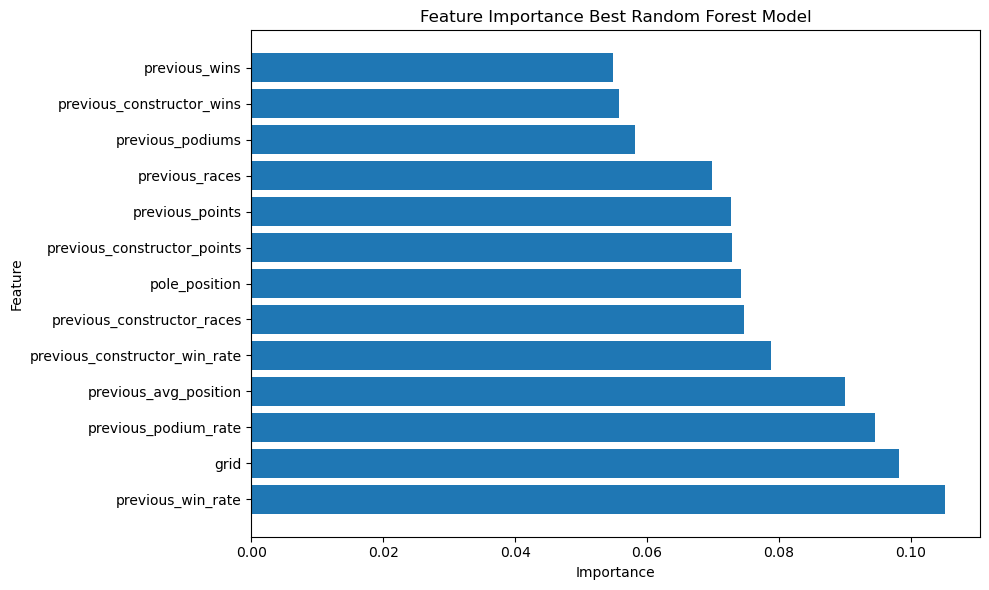

In [79]:
# Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['feature'],
    feature_importance['importance']
)

plt.title('Feature Importance Best Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()